In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" # Ensures IDs match nvidia-smi
os.environ["CUDA_VISIBLE_DEVICES"] = "4"

import random
from pathlib import Path

import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms

from PIL import Image

from preprocessing_module import find_class_names_filenames, stratified_split_data_paths, NatureCityScenesDataset
from trainer_class import Trainer

from ResNet import ResNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)

Device: cuda


In [4]:
DATASET_PATH = r"/itf-fi-ml/shared/courses/IN3310/mandatory1_data"

class_names, class_filenames = find_class_names_filenames(DATASET_PATH)
x_train_paths, x_val_paths, x_test_paths, y_train, y_val, y_test = stratified_split_data_paths(class_names, class_filenames)

train_set = NatureCityScenesDataset(DATASET_PATH, x_train_paths, y_train, transform=None)
val_set = NatureCityScenesDataset(DATASET_PATH, x_val_paths, y_val, transform=None)
test_set = NatureCityScenesDataset(DATASET_PATH, x_test_paths, y_test, transform=None)

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = NatureCityScenesDataset(DATASET_PATH, x_train_paths, y_train, transform=transform)
val_set = NatureCityScenesDataset(DATASET_PATH, x_val_paths, y_val, transform=transform)
test_set = NatureCityScenesDataset(DATASET_PATH, x_test_paths, y_test, transform=transform)

# --------------------------------------------------------------------------------------------------------------------------------

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

def batch_noise_augment(images: torch.Tensor, std: float = 0.03) -> torch.Tensor:
    noise = torch.randn_like(images) * std
    return torch.clamp(images + noise, -1.0, 1.0)

# --------------------------------------------------------------------------------------------------------------------------------

model_ResNet = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet.parameters(), lr=1e-4)

trainer_ResNet = Trainer(
    model=model_ResNet,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_ResNet.fit(train_loader, val_loader, epochs=num_epochs)

Epoch 01 | train loss: 0.7622, acc: 0.709 | val loss: 0.6239, acc: 0.779, acc_per_class: [0.76265824 0.85106385 0.7549296  0.75549453 0.66167665 0.89017344], mean average precision (mAP): 0.866, AP per class: [0.83601085 0.97900304 0.81699122 0.8646464  0.82073011 0.8805747 ]
Epoch 02 | train loss: 0.4685, acc: 0.829 | val loss: 0.5422, acc: 0.812, acc_per_class: [0.87341774 0.8905775  0.7943662  0.8131868  0.7694611  0.7369942 ], mean average precision (mAP): 0.894, AP per class: [0.87944214 0.98555083 0.84140941 0.86812176 0.90058627 0.88647151]
Epoch 03 | train loss: 0.3351, acc: 0.879 | val loss: 1.2111, acc: 0.702, acc_per_class: [0.44936708 0.993921   0.628169   0.8543956  0.8772455  0.39884394], mean average precision (mAP): 0.815, AP per class: [0.75800009 0.90002865 0.86624812 0.86949734 0.90486384 0.59257691]
Epoch 04 | train loss: 0.2417, acc: 0.916 | val loss: 0.7155, acc: 0.780, acc_per_class: [0.74050635 0.87234044 0.8422535  0.5934066  0.7335329  0.90751445], mean averag

In [ ]:
preds = torch.tensor([[0.20,0.25,0.05,0.50], [0.1,0.1,0.7,0.1], [0.5, 0.1, 0.2, 0.2], [0.2,0.6,0.1,0.1]])
targs = torch.tensor([3, 0, 2, 1])

correct_pred_classnumb = preds.argmax(dim=1) == targs
one_hot_targs = torch.nn.functional.one_hot(targs, num_classes=4)

actually_correct_preds_matrix = correct_pred_classnumb.unsqueeze(1)*one_hot_targs

acc_per_class = actually_correct_preds_matrix.sum(dim=0)/one_hot_targs.sum(dim=0)
acc_per_class.numpy()

array([0., 1., 0., 1.], dtype=float32)

In [5]:
trainer_ResNet.evaluate(test_loader)

EpochStats(loss=0.7342567791541418, acc=0.8079241812229156, mAP=0.8855188295928128, acc_per_class=array([0.7399577 , 0.9191919 , 0.80263156, 0.630713  , 0.8782435 ,
       0.88824666], dtype=float32), AP_per_class=array([0.86067638, 0.98277974, 0.83924828, 0.83576334, 0.89816686,
       0.89647837]))

In [6]:
# Move results from GPU to memory
results_dict = trainer_ResNet.history

In [ ]:
# Clean as much as possible of the GPU memory
import gc
if 'trainer_ResNet' in globals():
    del trainer_ResNet

if 'model' in globals():
    del model_ResNet

# 2. Force Python to find and remove "orphaned" memory references
gc.collect()

# 3. IMPORTANT: Tell PyTorch to give the memory back to the GPU pool
# Without this, nvidia-smi will still show the memory as "Used"
torch.cuda.empty_cache()

In [11]:
def plot_results(num_epochs, results_dict):

    epochs_list = np.arange(1, num_epochs+1)

    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs_list, results_dict["train_loss"], '.-', label="train loss")
    plt.plot(epochs_list, results_dict["val_loss"], '.-', label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()    

    plt.subplot(2, 2, 2)
    plt.plot(epochs_list, results_dict["train_acc"], '.-', label="train acc")
    plt.plot(epochs_list, results_dict["val_acc"], '.-', label="val acc")
    plt.plot(epochs_list, results_dict["val_mAP"], '.-', label="val mAP")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(2, 2, 3) 
    hist_arr_val_acc_per_class = np.asarray(results_dict["val_acc_per_class"])
    for class_number, class_name in enumerate(class_names):
        plt.plot(epochs_list, hist_arr_val_acc_per_class[:, class_number], ".-", label=f"Class {class_number}: {class_name}")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy, validation set")
    plt.legend()


    plt.subplot(2, 2, 4) 
    hist_arr_val_AP_per_class = np.asarray(results_dict["val_AP_per_class"])
    for class_number, class_name in enumerate(class_names):
        plt.plot(epochs_list, hist_arr_val_AP_per_class[:, class_number], ".-", label=f"Class {class_number}: {class_name}")

    plt.xlabel("Epoch")
    plt.ylabel("Precision, validation set")
    plt.legend()

    plt.tight_layout()
    plt.show()

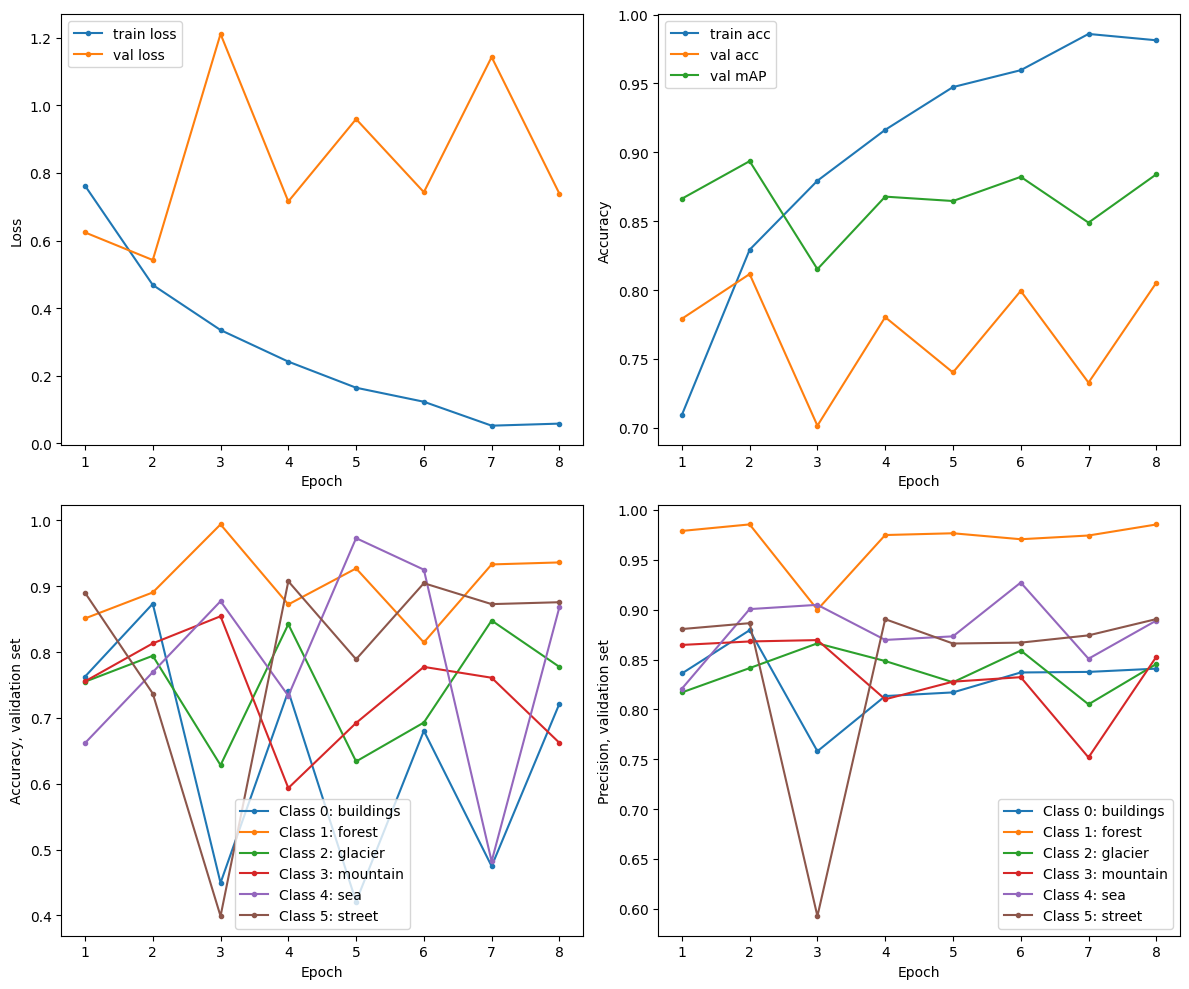

In [12]:
plot_results(num_epochs, results_dict)

In [ ]:
torch_model_resnet18 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /itf-fi-ml/home/johnmagj/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s] 


In [24]:
torch_model_resnet18.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  